In [5]:
import pandas as pd
import numpy as np

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\radha\Downloads\Employee-Attrition - Employee-Attrition.csv")

# One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
lr_model = LogisticRegression(random_state=42)

In [8]:
lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

In [9]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [10]:
print(y_pred_lr)

[0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0
 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0]


In [11]:
from sklearn.metrics import accuracy_score

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:", accuracy)

Accuracy: 0.7755102040816326


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[200  47]
 [ 19  28]]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.81      0.86       247
           1       0.37      0.60      0.46        47

    accuracy                           0.78       294
   macro avg       0.64      0.70      0.66       294
weighted avg       0.83      0.78      0.79       294



In [15]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7551020408163265

Confusion Matrix
[[206  41]
 [ 31  16]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       247
           1       0.28      0.34      0.31        47

    accuracy                           0.76       294
   macro avg       0.57      0.59      0.58       294
weighted avg       0.78      0.76      0.76       294



In [16]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8299319727891157

Confusion Matrix
[[234  13]
 [ 37  10]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       247
           1       0.43      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.65      0.58      0.59       294
weighted avg       0.79      0.83      0.80       294



In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Create Base Model
rf = RandomForestClassifier(random_state=42)

# Parameter Grid
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train_smote, y_train_smote)

# Best Parameters
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [18]:
#Train the Optimized Random Forest

# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Optimized Random Forest Model
best_rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=None,
    random_state=42
)

# Train Model
best_rf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_best_rf = best_rf.predict(X_test_scaled)

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Optimized Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_best_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best_rf))

Optimized Random Forest Accuracy: 0.8367346938775511

Confusion Matrix
[[235  12]
 [ 36  11]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       247
           1       0.48      0.23      0.31        47

    accuracy                           0.84       294
   macro avg       0.67      0.59      0.61       294
weighted avg       0.80      0.84      0.81       294



In [19]:
!pip install xgboost

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8741496598639455

Confusion Matrix
[[239   8]
 [ 29  18]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



AUC Score: 0.7962787492462744


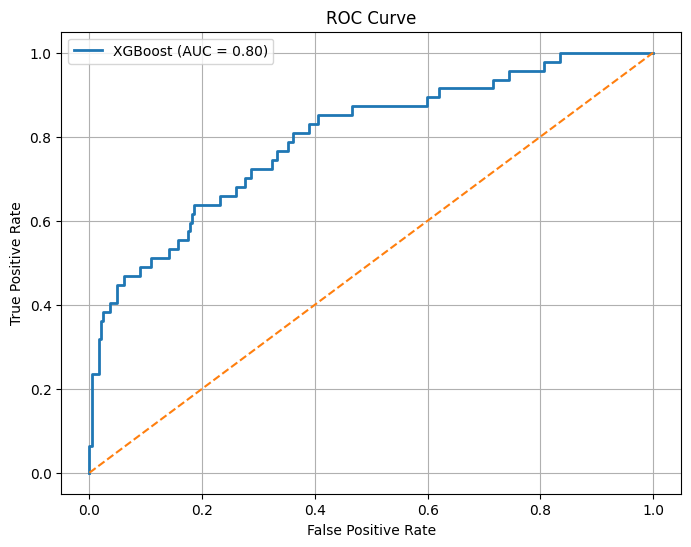

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability Prediction
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.2f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

                             Feature  Importance
43                      OverTime_Yes    0.123580
37         JobRole_Research Director    0.114180
7                           JobLevel    0.070254
15                  StockOptionLevel    0.060965
22              YearsWithCurrManager    0.044111
33           JobRole_Human Resources    0.039656
30              EducationField_Other    0.036265
8                    JobSatisfaction    0.030785
23  BusinessTravel_Travel_Frequently    0.029741
26                  Department_Sales    0.026816


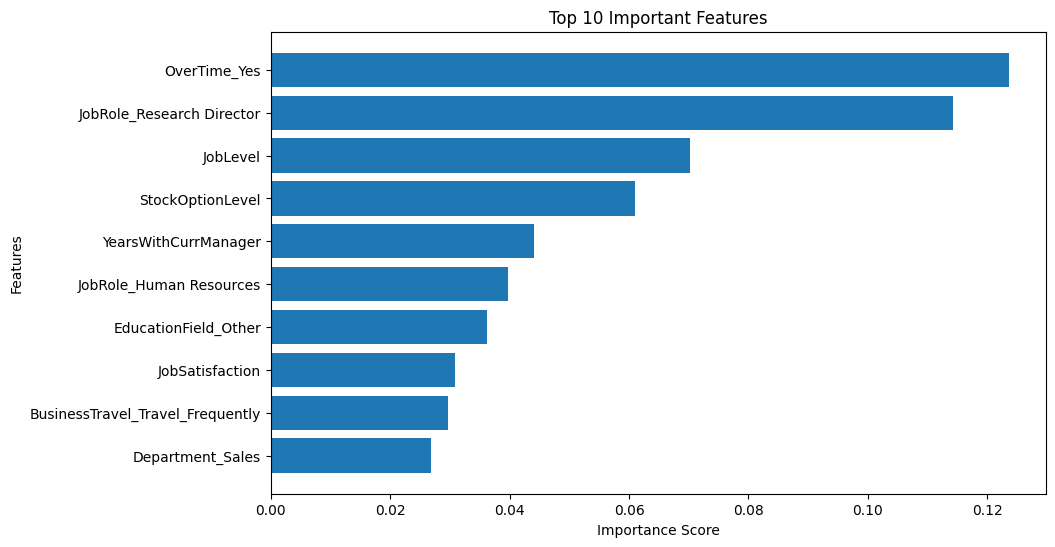

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7755,
        0.7551,
        0.8299,
        0.8367,
        0.8741
    ],
    "Precision": [
        0.37,
        0.28,
        0.43,
        0.48,
        0.69
    ],
    "Recall": [
        0.60,
        0.34,
        0.21,
        0.23,
        0.38
    ],
    "F1 Score": [
        0.46,
        0.31,
        0.29,
        0.31,
        0.49
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7755,0.37,0.60,0.46
1,Decision Tree,0.7551,0.28,0.34,0.31
2,Random Forest,0.8299,0.43,0.21,0.29
3,Optimized Random Forest,0.8367,0.48,0.23,0.31
4,XGBoost,0.8741,0.69,0.38,0.49


In [ ]:
# Final Model Selection

Five machine learning models were developed and evaluated for predicting employee attrition.

Among all the models, XGBoost achieved the highest overall accuracy (87.41%) and the highest precision (0.69), making it the best-performing model. Although Logistic Regression achieved a higher recall (0.60), XGBoost provided a better overall balance between precision, recall, and F1-score.

Therefore, XGBoost was selected as the final model for deployment.

In [25]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Model
joblib.dump(xgb_model, "../models/best_model.pkl")

# Save Scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save Feature Columns
joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

print("Files Saved Successfully!")

Files Saved Successfully!


In [ ]:
# Conclusion

The objective of this project was to predict employee attrition using Machine Learning techniques.

Several classification algorithms were implemented and compared, including Logistic Regression, Decision Tree, Random Forest, Optimized Random Forest, and XGBoost.

Among them, XGBoost achieved the best overall performance.

The analysis showed that employee overtime, job role, job level, stock option level, and job satisfaction are among the major factors influencing employee attrition.

This predictive model can assist HR departments in identifying employees at risk and implementing proactive retention strategies.

In [ ]:
# Business Recommendations

#• Reduce excessive overtime.

#• Improve employee job satisfaction.

#• Review employee stock option policies.

#• Provide career growth opportunities.

#• Focus retention strategies on employees identified as high risk.

#• Conduct regular employee engagement surveys.

In [25]:
print("Employee Attrition Prediction Project Completed Successfully")

Employee Attrition Prediction Project Completed Successfully


In [26]:
print(X.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_

In [1]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\radha\OneDrive\Documents\project guvi\Employee_Attrition_Project\notebooks


In [26]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>
